# Hot Dog or Not Hot Dog – Convolutional Neural Network Course for Beginners

https://www.youtube.com/watch?v=nVhau51w6dM

https://colab.research.google.com/drive/1G_ixTTBy6tVm4R7B7qYEdokjilLBdLdq?usp=sharing#scrollTo=MbSzT4i8pZBj
https://docs.google.com/presentation/d/16Z2fnBl2azfGxZ8InHiFvRb1OLZVQTLQpy8GzZR5YEg/edit?slide=id.geafe5a2fec_0_0#slide=id.geafe5a2fec_0_0

Dataset:
https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import tensorflow as tf
from tensorflow.keras import datasets, layers, models

import tensorflow_datasets as tfds

@inproceedings{bossard14,
  title = {Food-101 -- Mining Discriminative Components with Random Forests},
  author = {Bossard, Lukas and Guillaumin, Matthieu and Van Gool, Luc},
  booktitle = {European Conference on Computer Vision},
  year = {2014}
}

Data

TensorFlow has the food 101 dataset already. We will use this! https://www.tensorflow.org/datasets/catalog/food101
Hot dog is label 55

https://www.kaggle.com/datasets/dansbecker/food-101

In [2]:
ds, ds_info = tfds.load('food101', shuffle_files=True, as_supervised=True, with_info=True)

In [3]:
train_ds, valid_ds = ds["train"], ds["validation"]

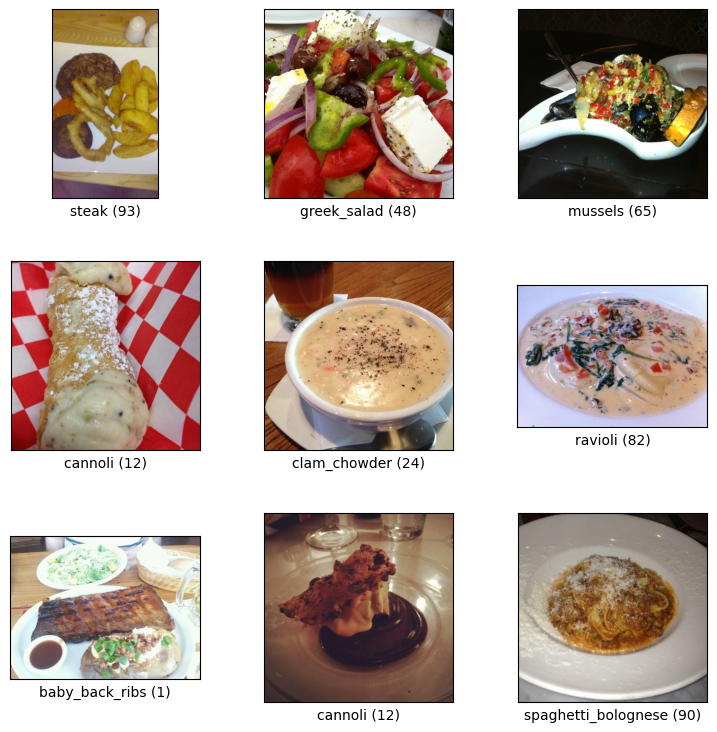

In [4]:
fig = tfds.show_examples(train_ds, ds_info)

In [5]:
MAX_SIDE_LEN = 128
HOT_DOG_CLASS = 55
train_ds = train_ds.map(
    lambda image, label: (tf.cast(tf.image.resize(image, [MAX_SIDE_LEN, MAX_SIDE_LEN]), dtype=tf.int32),
                          tf.cast(label == HOT_DOG_CLASS, dtype=tf.int32))
)

valid_ds = valid_ds.map(
    lambda image, label: (tf.cast(tf.image.resize(image, [MAX_SIDE_LEN, MAX_SIDE_LEN]), dtype=tf.int32),
                          tf.cast(label == HOT_DOG_CLASS, dtype=tf.int32))
)

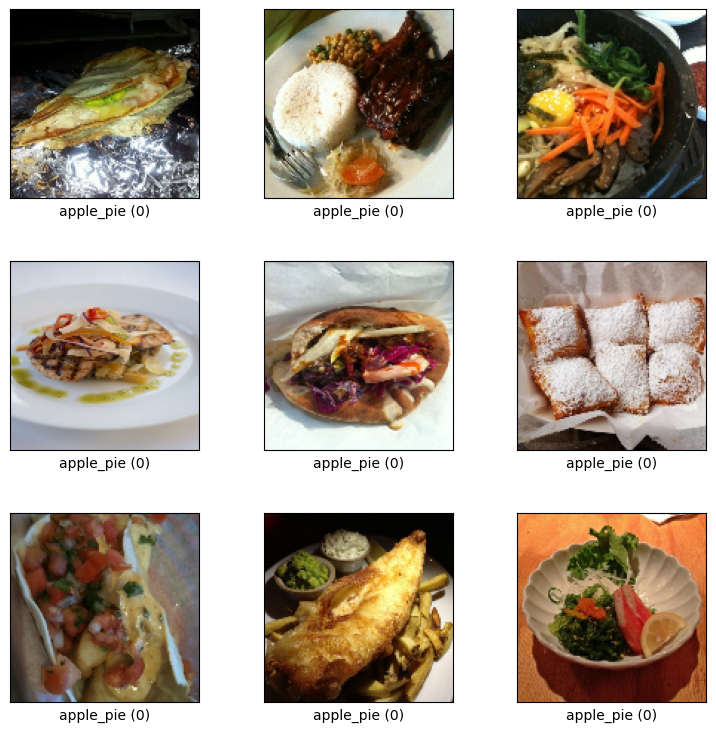

In [6]:
fig = tfds.show_examples(train_ds, ds_info)

In [7]:
train_hd_size, valid_hd_size = 750, 250
train_hotdogs = train_ds.filter(lambda image, label: label == 1).repeat(3)
train_nothotdogs = train_ds.filter(lambda image, label: label == 0)

In [8]:
valid_hotdogs = valid_ds.filter(lambda image, label: label == 1).repeat(3)
valid_nothotdogs = valid_ds.filter(lambda image, label: label == 0)

In [9]:
batch_size = 16

train_ds = tf.data.Dataset.sample_from_datasets([train_hotdogs, train_nothotdogs],
                                                [0.5, 0.5],
                                                stop_on_empty_dataset=True)
train_ds = train_ds.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)

valid_ds = tf.data.Dataset.sample_from_datasets([valid_hotdogs, valid_nothotdogs],
                                                [0.5, 0.5],
                                                stop_on_empty_dataset=True)
valid_ds = valid_ds.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [10]:
for image_batch, label_batch in train_ds.take(1):
    print(image_batch)
    print(label_batch)

tf.Tensor(
[[[[  1   1   1]
   [  1   1   1]
   [  1   1   1]
   ...
   [101 116 123]
   [124 137 145]
   [141 152 156]]

  [[  1   1   1]
   [  1   1   1]
   [  1   1   1]
   ...
   [ 80  95 102]
   [ 94 107 115]
   [107 118 122]]

  [[  1   1   1]
   [  1   1   1]
   [  1   1   1]
   ...
   [136 146 147]
   [138 149 153]
   [136 145 142]]

  ...

  [[134  25  28]
   [134  25  28]
   [134  25  28]
   ...
   [158  51  69]
   [159  52  68]
   [160  53  68]]

  [[129  25  24]
   [133  24  26]
   [135  25  27]
   ...
   [154  46  62]
   [157  49  65]
   [160  52  67]]

  [[130  26  22]
   [133  25  23]
   [134  24  23]
   ...
   [155  48  67]
   [157  50  70]
   [159  52  73]]]


 [[[  0   7   6]
   [  0   6   6]
   [  0   4   5]
   ...
   [115 151 208]
   [115 153 208]
   [118 158 208]]

  [[  0   5   4]
   [  2   8   8]
   [  0   4   5]
   ...
   [111 146 202]
   [109 146 200]
   [112 151 201]]

  [[  0   6   5]
   [  1   7   7]
   [  1   6   6]
   ...
   [116 150 205]
   [111 147 200]


### Neural Net Implementation

In [11]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip('horizontal'),
  tf.keras.layers.RandomRotation(0.2),
])

In [12]:
for i,_ in ds["train"].take(1):
    image = i

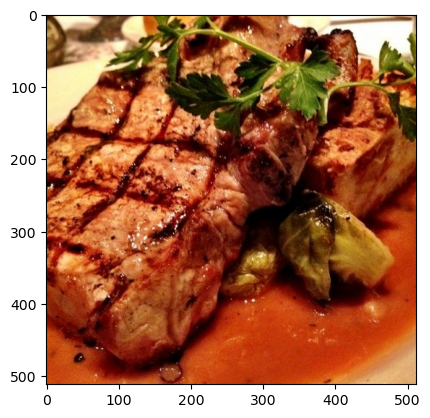

In [13]:
plt.imshow(image)

In [14]:
image = tf.cast(tf.expand_dims(image, 0), tf.float32)
image /= 255.0

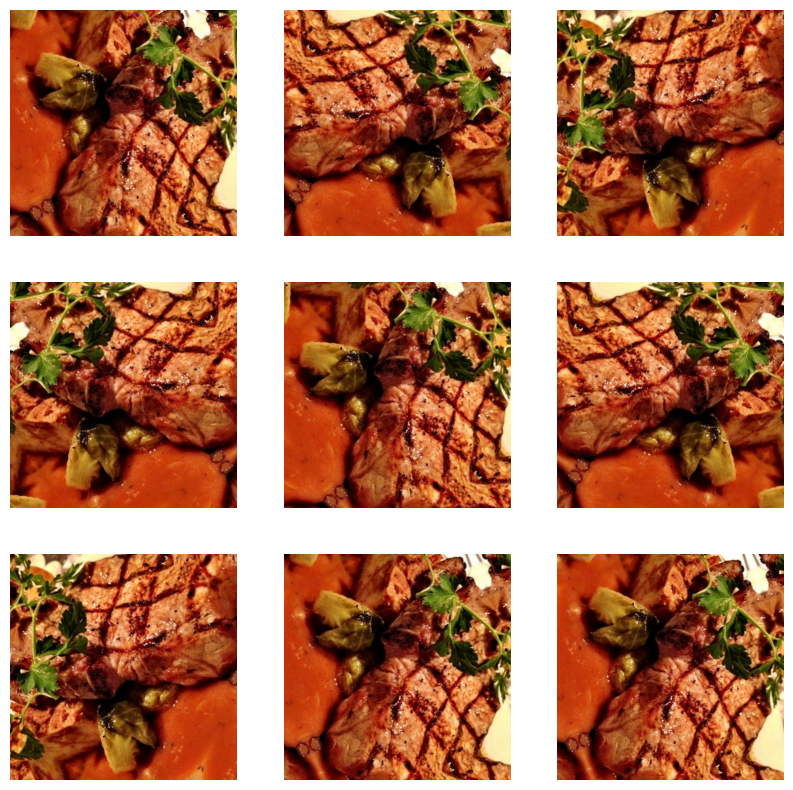

In [15]:
plt.figure(figsize=(10, 10))
for i in range(9):
    augmented_image = data_augmentation(image)
    ax = plt.subplot(3, 3, i+1)
    plt.imshow(augmented_image[0])
    plt.axis("off")

In [16]:
random.seed(0)
model = models.Sequential()
model.add(layers.Rescaling(1./255))
# model.add(data_augmentation)
model.add(layers.Conv2D(64, (3, 3), activation='relu', input_shape=(MAX_SIDE_LEN, MAX_SIDE_LEN, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.25))
model.add(layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(l2=0.01)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.25))
model.add(layers.Conv2D(32, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(l2=0.01)))
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.25))
model.add(layers.Dense(1))

c:\Users\jc\anaconda3\envs\ece\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
lr = 0.0001
model.compile(optimizer=tf.keras.optimizers.Adam(lr),
                loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
                metrics=["accuracy"])

In [18]:
epochs = 50
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=epochs,
    verbose=1
)

Epoch 1/50


c:\Users\jc\anaconda3\envs\ece\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


    279/Unknown 37s 128ms/step - accuracy: 0.5064 - loss: 1.4598

c:\Users\jc\anaconda3\envs\ece\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


279/279 ━━━━━━━━━━━━━━━━━━━━ 46s 161ms/step - accuracy: 0.5064 - loss: 1.4598 - val_accuracy: 0.5259 - val_loss: 1.2147
Epoch 2/50
279/279 ━━━━━━━━━━━━━━━━━━━━ 23s 83ms/step - accuracy: 0.5493 - loss: 1.0713 - val_accuracy: 0.5430 - val_loss: 0.9683
Epoch 3/50
279/279 ━━━━━━━━━━━━━━━━━━━━ 25s 89ms/step - accuracy: 0.5788 - loss: 0.8974 - val_accuracy: 0.5740 - val_loss: 0.8569
Epoch 4/50
279/279 ━━━━━━━━━━━━━━━━━━━━ 25s 89ms/step - accuracy: 0.6044 - loss: 0.8105 - val_accuracy: 0.5923 - val_loss: 0.7898
Epoch 5/50
279/279 ━━━━━━━━━━━━━━━━━━━━ 25s 89ms/step - accuracy: 0.6318 - loss: 0.7502 - val_accuracy: 0.6271 - val_loss: 0.7473
Epoch 6/50
279/279 ━━━━━━━━━━━━━━━━━━━━ 25s 89ms/step - accuracy: 0.6554 - loss: 0.7042 - val_accuracy: 0.6403 - val_loss: 0.7166
Epoch 7/50
279/279 ━━━━━━━━━━━━━━━━━━━━ 25s 88ms/step - accuracy: 0.6849 - loss: 0.6620 - val_accuracy: 0.6574 - val_loss: 0.7064
Epoch 8/50
279/279 ━━━━━━━━━━━━━━━━━━━━ 24s 88ms/step - accuracy: 0.7186 - loss: 0.6200 - val_accura

In [19]:
plt.figure(figsize=(10, 10))
for image_batch, label_batch in valid_ds.take(1):
  images = image_batch
  labels = label_batch

<Figure size 1000x1000 with 0 Axes>

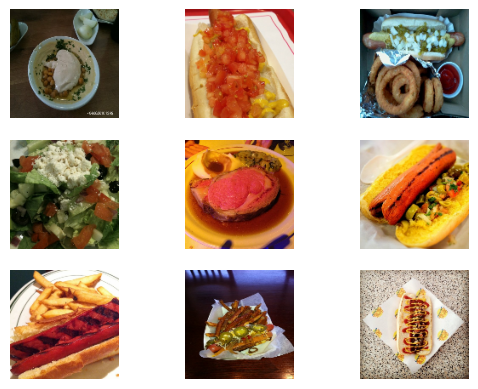

In [20]:
for i in range(9):
  ax = plt.subplot(3, 3, i+1)
  plt.imshow(images[i])
  plt.axis("off")

In [21]:
labels[:9]

<tf.Tensor: shape=(9,), dtype=int32, numpy=array([0, 1, 1, 0, 0, 1, 1, 1, 1], dtype=int32)>